# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 07     |  |
| :-------------|:-------------|
| Lieke Boontjes| 6543715 |
| Yu He Zhang| 6455417 |
| Zulfiqar Alwani| 6281265 |

In [2]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Lieke', 'Yu He','Zul']

## Opdracht 1: Planning.

| Planning Groep: 7     |Tijdstip / Tijdspanne  |
|---|---|
| kalibreren | 11:00-11:15 |
| testen meetopstelling | 11:15-12:00 |
| individueel algoritme | 12:00-12:30 |
| pauze | 12:30-13:30 |
| itereren | 13:30-16:00 |
| conclusies en afronden | 16:00-eind |
| groep aanwezig 1| 11:00 |
| groep aanwezig 2| 13:30 |
| Pauze 1| 12:30-13:30 |
| Pauze 2| 15:00-15:15 |

## Opdracht 2: Import libs.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [7]
<img src="opstellingopdracht4.jpeg" width="400">


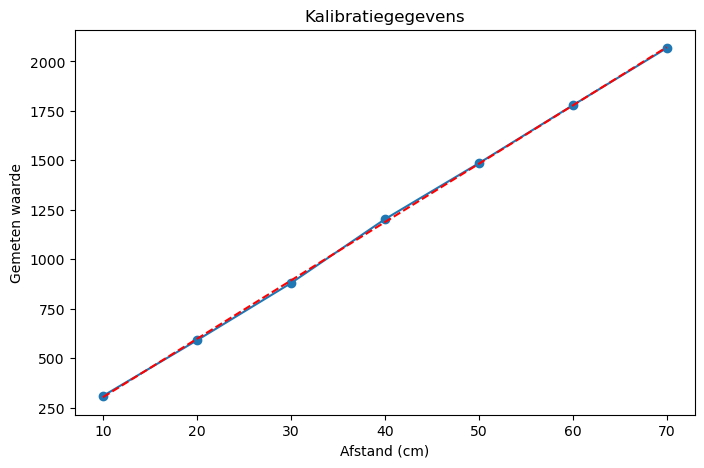

Kalibratieparameters: a = 29.485714285714288 b = 7.714285714285391


In [ ]:
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
afstand = np.array([ 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70 ])*100 # in cm
metingen_kalibratie = np.array([ 309, 590, 879, 1202,1485, 1778, 2067])

def lineaire_functie(x, a, b): 
    return a * x + b
params, covariance = curve_fit(lineaire_functie, afstand, metingen_kalibratie)

plt.figure(figsize=(8, 5))
plt.plot(afstand, metingen_kalibratie, 'o-')
plt.plot(afstand, lineaire_functie(afstand, *params), 'r--', label='Fit: a=%.2f, b=%.2f' % tuple(params))
plt.xlabel('Afstand (cm)')
plt.ylabel('Gemeten waarde')
plt.title('Kalibratiegegevens')
plt.show()
print("Kalibratieparameters: a =", params[0], "b =", params[1])


#in arduino voeren we als alpha in 0.0294857 en als beta 0.77142
#zie output van kalibratieparameters hieronder geprint




## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  40   0  30  36.80
1   0  30   0  20  37.93
2  40   0  30   0  37.19
3  30   0  20   0  37.80
4  10   0  20   0  42.75


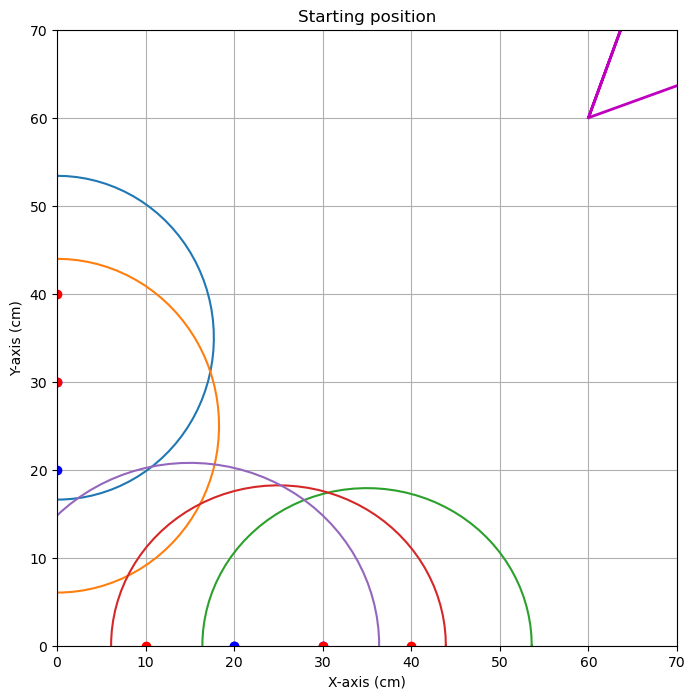


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=106.770


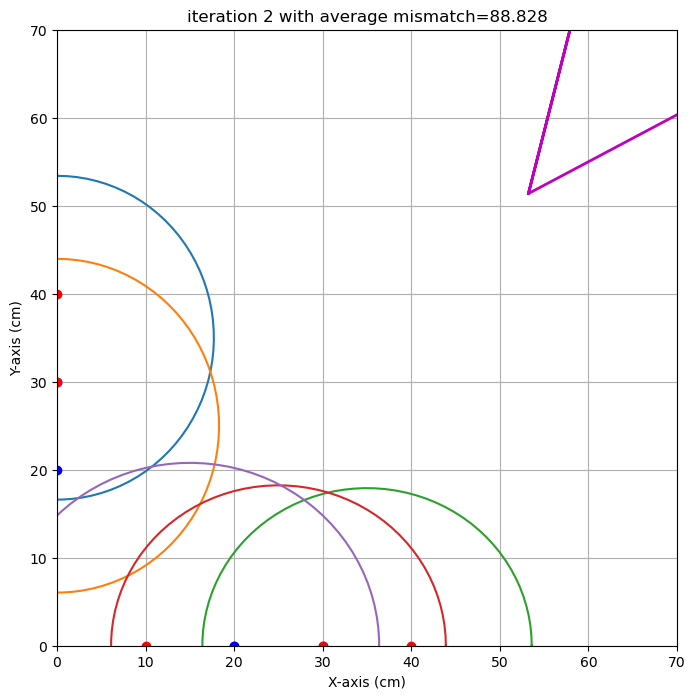

end iteration 2 with average mismatch=88.828


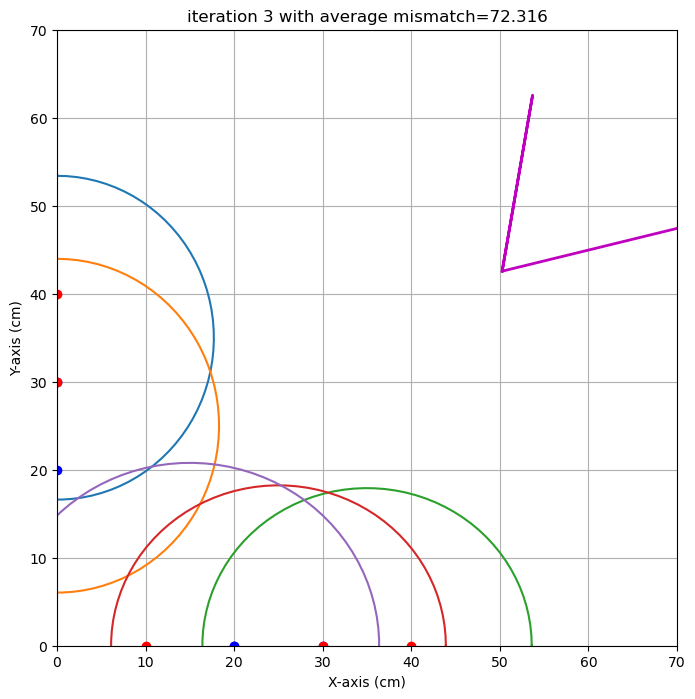

end iteration 3 with average mismatch=72.316


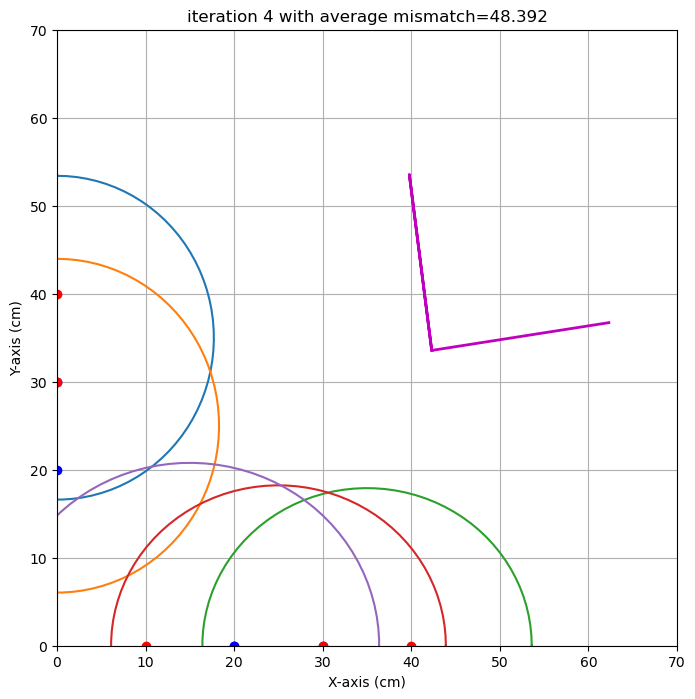

end iteration 4 with average mismatch=48.392


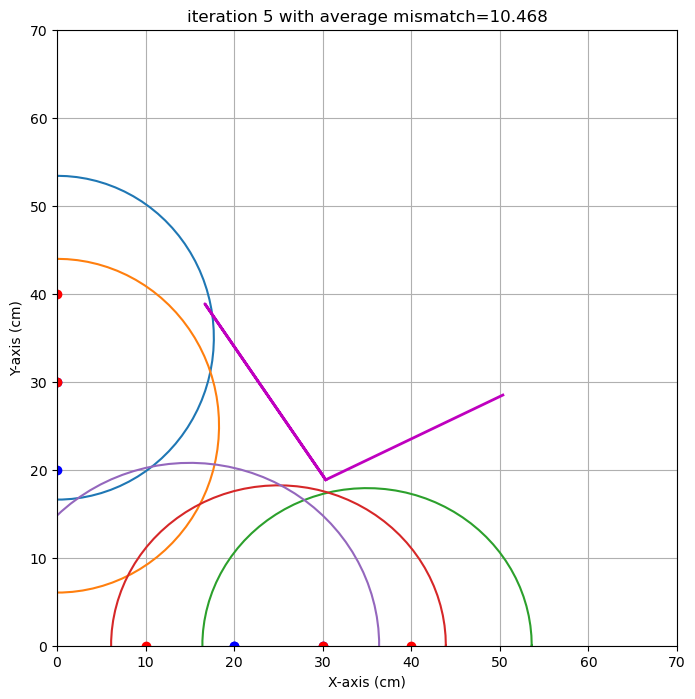

end iteration 5 with average mismatch=10.468


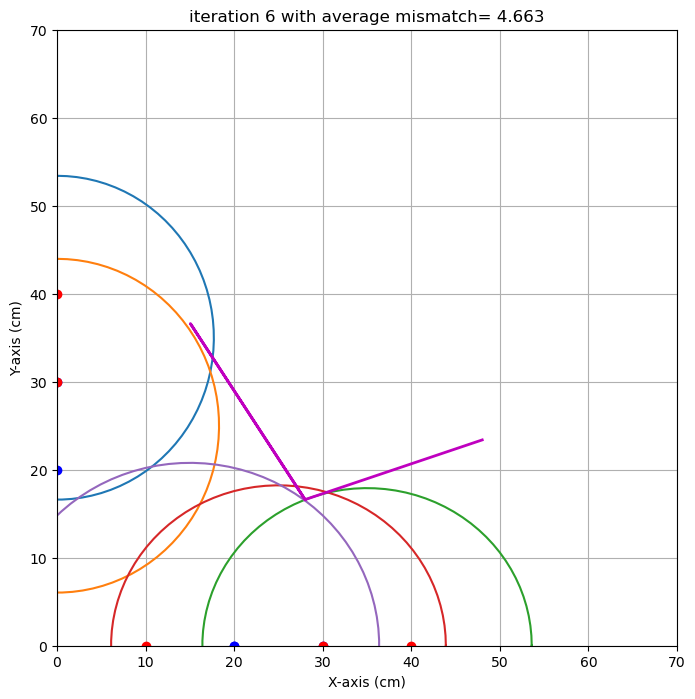

end iteration 6 with average mismatch= 4.663
end iteration 7 with average mismatch= 4.653
end iteration 8 with average mismatch= 4.565
end iteration 9 with average mismatch= 4.536
end iteration 10 with average mismatch= 4.453
end iteration 11 with average mismatch= 4.439
end iteration 12 with average mismatch= 4.356
end iteration 13 with average mismatch= 4.136
end iteration 14 with average mismatch= 4.136
end iteration 15 with average mismatch= 4.136
end iteration 16 with average mismatch= 4.136
end iteration 17 with average mismatch= 4.136


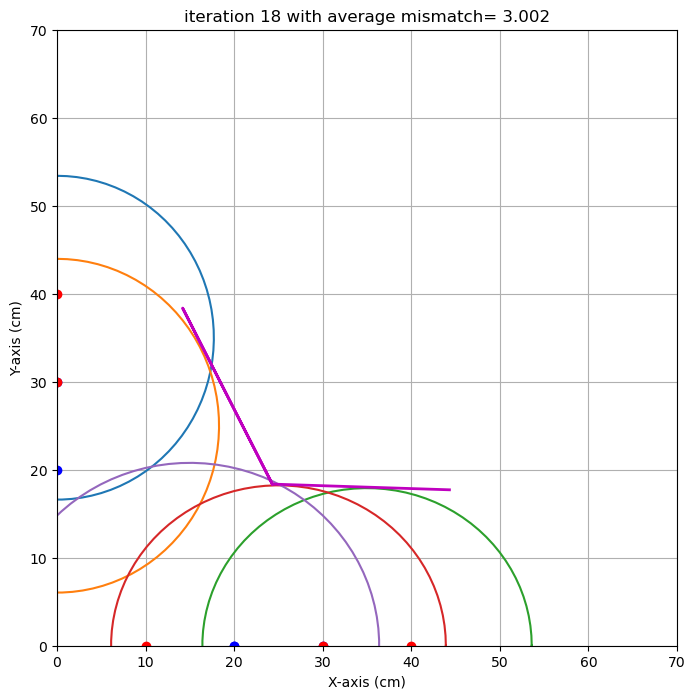

end iteration 18 with average mismatch= 3.002


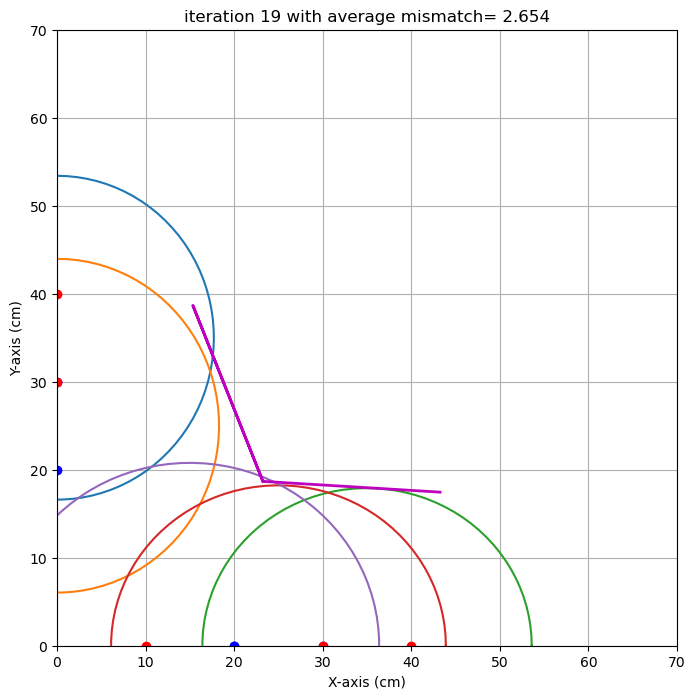

end iteration 19 with average mismatch= 2.654


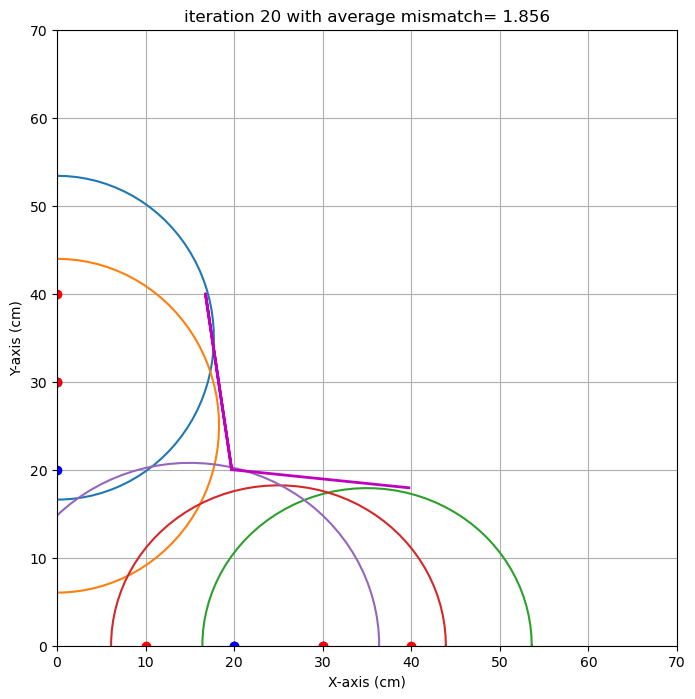

end iteration 20 with average mismatch= 1.856


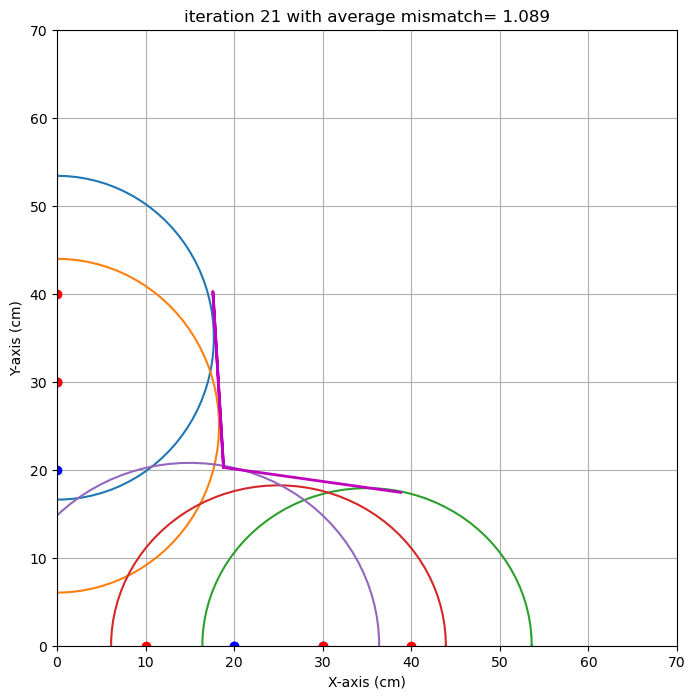

end iteration 21 with average mismatch= 1.089


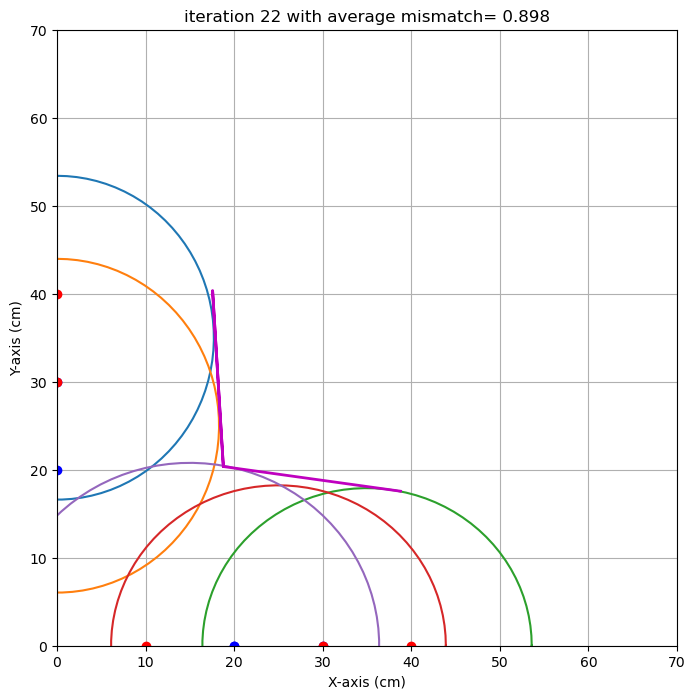

end iteration 22 with average mismatch= 0.898
end iteration 23 with average mismatch= 0.889
end iteration 24 with average mismatch= 0.878
end iteration 25 with average mismatch= 0.857
end iteration 26 with average mismatch= 0.816
end iteration 27 with average mismatch= 0.811
end iteration 28 with average mismatch= 0.801
end iteration 29 with average mismatch= 0.795
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.795
###############################################################################
end of iteration  30
Best alpha=  -8.02 with uncertainty=   0.00
Best beta =  -3.54 with uncertainty=   0.00
Best x0   =  18.68 with uncertainty=   0.00
Best y0   =  20.34 with uncertainty=   0.00
###############################################################################
no uncertainty found, please run again


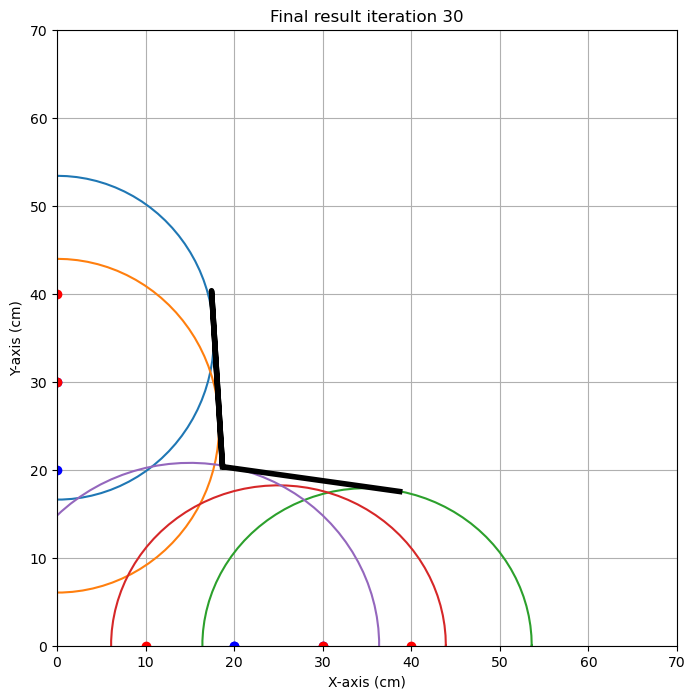

In [ ]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,36.80],
    [0,30,0,20,37.93],
    #[0,10,0,20,77.71], deze meet niks
    [40,0,30,0,37.19],
    [30,0,20,0,37.80],
    [10,0,20,0,42.75],
    #[10,0,0,10,150.70]  # ontvanger en bron staan beetje gedraaid, anders geen datapunt gegenereerd door arduino krijgen te gote waars reflecteerd dus niet op papier 
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [24]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 18.7 cm met een standaardafwijking van 0.0 cm 
y0: 20.3 cm met een standaardafwijking van 0.0 cm 
alpha: -8.0 graden met een standaardafwijking van 0.0 graad 
beta: -3.5 graden met een standaardafwijking van 0.0 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Yu He Zhang]
Voeg een foto in van het algoritme van het eerste groepslid
<img src="AlgoritmeDEF4YuHe.png" width="400">

#### algoritme [Zul]
Voeg een foto in van het algoritme van het tweede groepslid
<img src="AlgoritmeDEFzul.jpg" width="400">

#### algoritme [Lieke]
Voeg een foto in van het algoritme van het derde groepslid
<img src="AlgoritmeDEF4moi.jpg" width="400">

In [6]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [ ]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':23,  #zelf aanvullen,
           'y0':45, #zelf aanvullen,
           'alpha' : -20, #zelf aanvullen,
           'beta' : 45, #zelf aanvullen},
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Yu He' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0, 40, 40, 0, 55.2]
    [0,40,0,60,33.7]
    [0,30,0,60,37.1]
    [0,35,0,50,26.3]
    [0,50,0,60,125.7]
    [10,0,25,0, 36.2]
    [15,0,35,0, 37.3]
    [15,0,20,0,34.2]
    [10,0,40,0, 41.5]
    [50,0,20,0, 40.6]
    [0,25,0,50,33.7]
    #zelf aanvullen
    ]),
       'Lieke' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
   #[40,0,0,40, 51.6],
   [0,40,0,60, 55.8], 
   #[0,35,0,50,128.0 ], 
   [10,0,25,0, 65.1 ], 
   [15,0,35,0, 62.1 ],
   #[0,50,0,70, ],
    #zelf aanvullen
    ]),
       'Zul' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #zelf aanvullen, datapunten op x-as van de transmitter constant laten toenemen, en zelfde principe op de 5 punten op de y-as
    #Daarnaast datapunt van receiver constant gehouden, voor hopelijk betrouwbare beginmetingen, en kleinere onzekerheid in alpha en beta
    [10,0,20,0, 66.2],
   #[25,0,20,0, 61.3 ], 
   [30,0,20,0, 60.4 ], 
   [40,0,20,0, 59.4], 
   [50,0,20,0, 62.2 ],
   [0,10,0,20, 46.2 ],
   [0,20,0,25, 129.1 ], 
   [0,30,0,20, 132.0 ], 
   #[0,40,0,20, 103.8 ], 
   #[0,50,0,20, 113.4 ], 
    ])
      }

[30,0,50,0,167.57],
   #[30,0,70,0, ], geen resultaat
   #[50,0,70,0, ], geen resultaat
   [0,30,0,50,130.7 ], 
   [0,30,0,70, 80 ],
   [0,50,0,70, 67 ],

resultaatalgor1itteratie1 = imagingDEF.imagingDEF(data.get('Zul'))

IndentationError: unexpected indent (1626999102.py, line 56)

## Opdracht 7: Evaluatie.

In [8]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

naam1


NameError: name 'data' is not defined

In [9]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

NameError: name 'targets' is not defined

## Opdracht 8: Iteratie1+ 1600
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](tudelftLogo.png)


In [10]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
    xs  ys  xr  yr      R
0    0  40  40   0   55.2
1    0  40   0  60   33.7
2    0  30   0  60   37.1
3    0  35   0  50   26.3
4    0  50   0  60  125.7
5   10   0  25   0   36.2
6   15   0  35   0   37.3
7   15   0  20   0   34.2
8   10   0  40   0   41.5
9   50   0  20   0   40.6
10   0  25   0  50   33.7


c:\Users\lieke\miniconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


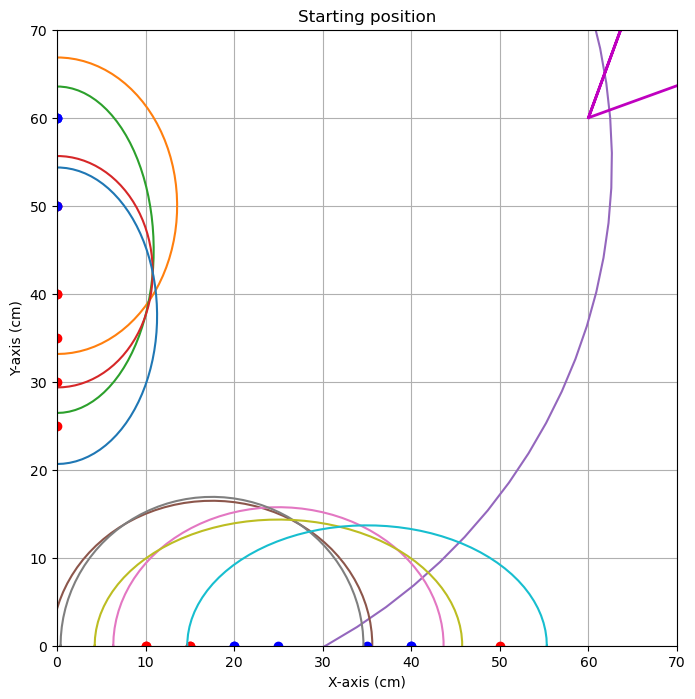


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=94.877
end iteration 2 with average mismatch=88.065


c:\Users\lieke\miniconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


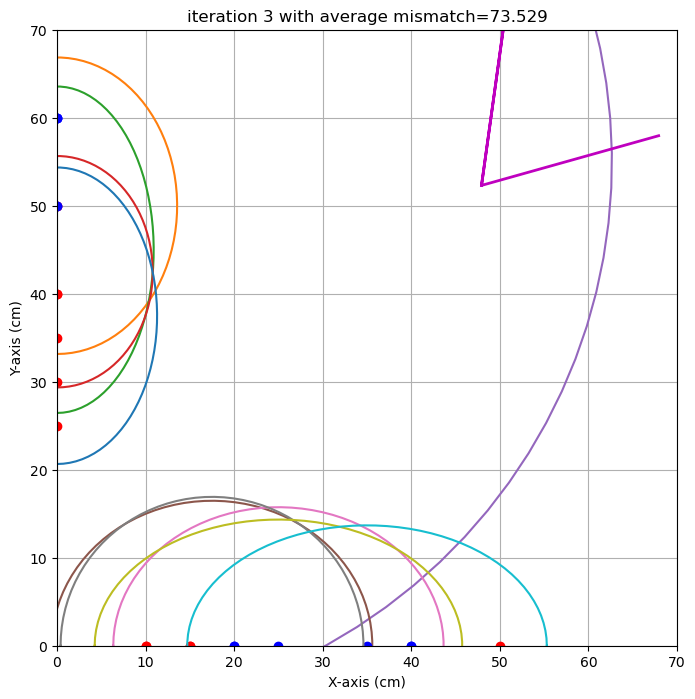

end iteration 3 with average mismatch=73.529


c:\Users\lieke\miniconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


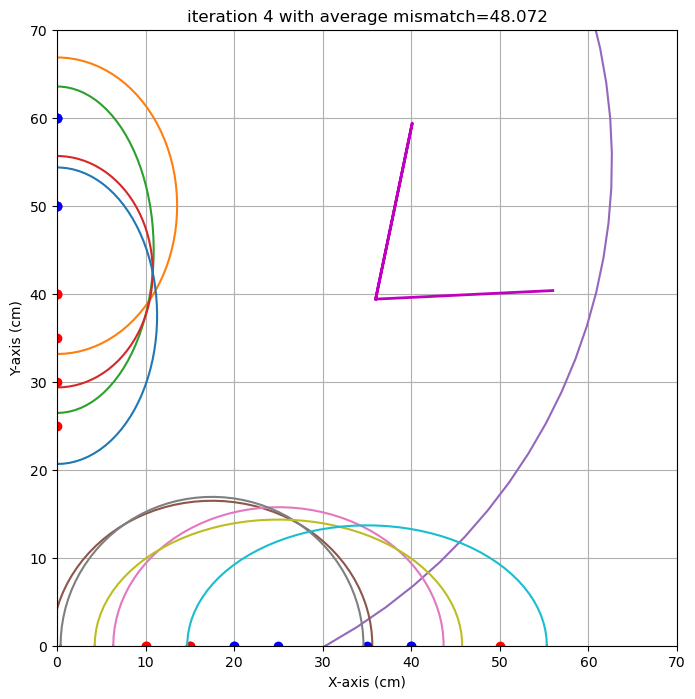

end iteration 4 with average mismatch=48.072


c:\Users\lieke\miniconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


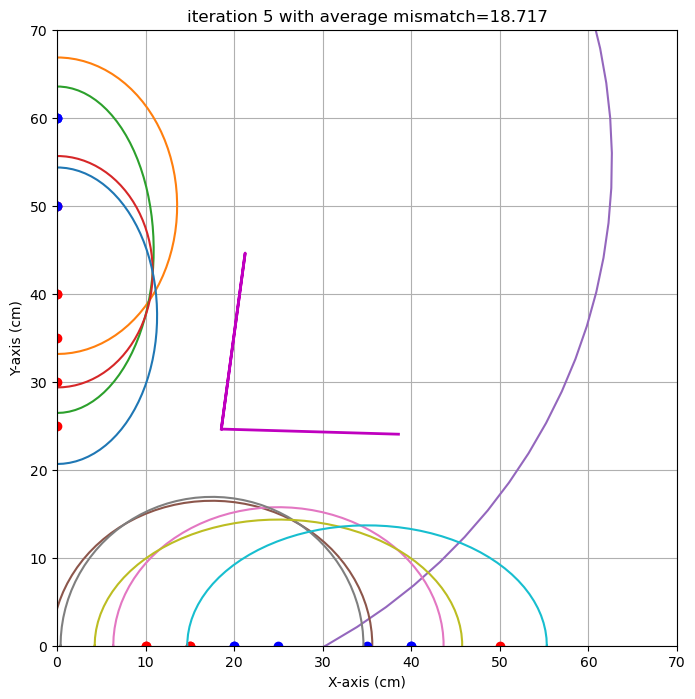

c:\Users\lieke\miniconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


end iteration 5 with average mismatch=18.717


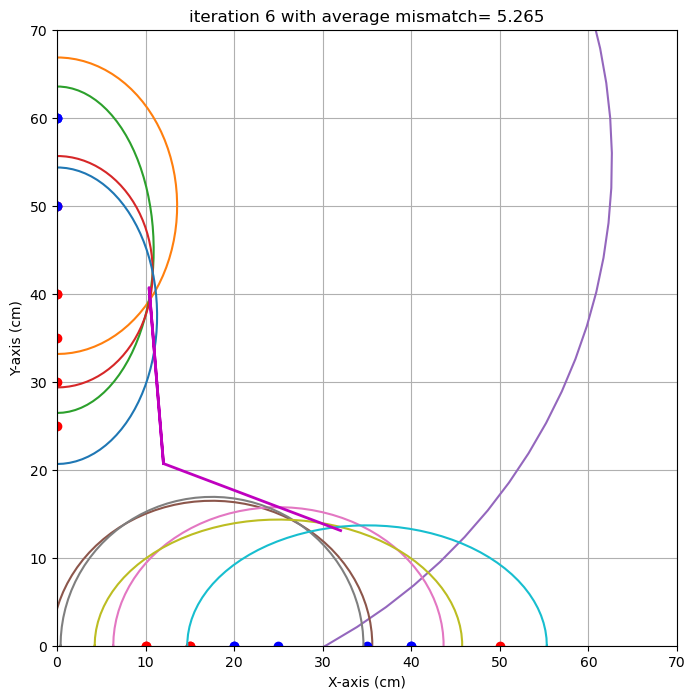

end iteration 6 with average mismatch= 5.265
end iteration 7 with average mismatch= 5.216
end iteration 8 with average mismatch= 5.185
end iteration 9 with average mismatch= 5.185
end iteration 10 with average mismatch= 5.185
end iteration 11 with average mismatch= 5.185
end iteration 12 with average mismatch= 5.185
end iteration 13 with average mismatch= 5.185
end iteration 14 with average mismatch= 5.185
end iteration 15 with average mismatch= 5.185
end iteration 16 with average mismatch= 5.185
end iteration 17 with average mismatch= 5.176
end iteration 18 with average mismatch= 5.169
end iteration 19 with average mismatch= 5.168
end iteration 20 with average mismatch= 5.168
end iteration 21 with average mismatch= 5.168
end iteration 22 with average mismatch= 5.168
end iteration 23 with average mismatch= 5.162
end iteration 24 with average mismatch= 5.162
end iteration 25 with average mismatch= 5.162
end iteration 26 with average mismatch= 5.162
end iteration 27 with average mismatch

c:\Users\lieke\miniconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


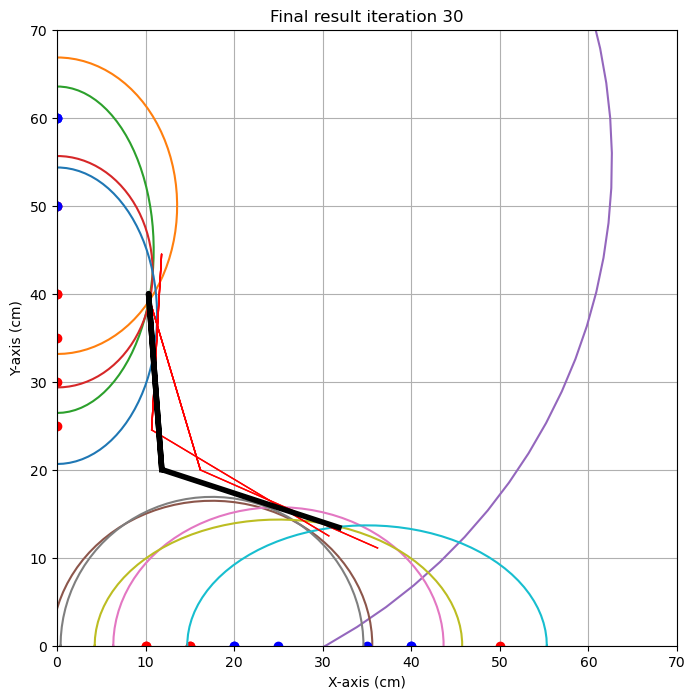

{'alpha': np.float64(-18.21721397018641), 'alpha_eps': np.float64(12.823514003491763), 'beta': np.float64(-4.2756023583369585), 'beta_eps': np.float64(12.229879675928327), 'x0': np.float64(11.828151943790608), 'x0_eps': np.float64(4.358437042599682), 'y0': np.float64(20.017018314572603), 'y0_eps': np.float64(4.503315361189575)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40  40   0  56.3
1   0  15   0  35  33.5
2   0  10   0  25  32.4
3  15   0  35   0  33.2
4  10   0  25   0  33.6
5   0   0   0  50  52.0
6   0   0  50   0  63.4
7   0  10   0  40  38.0
8  10   0  40   0  39.6
9  15   0  20   0  29.2


c:\Users\lieke\miniconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


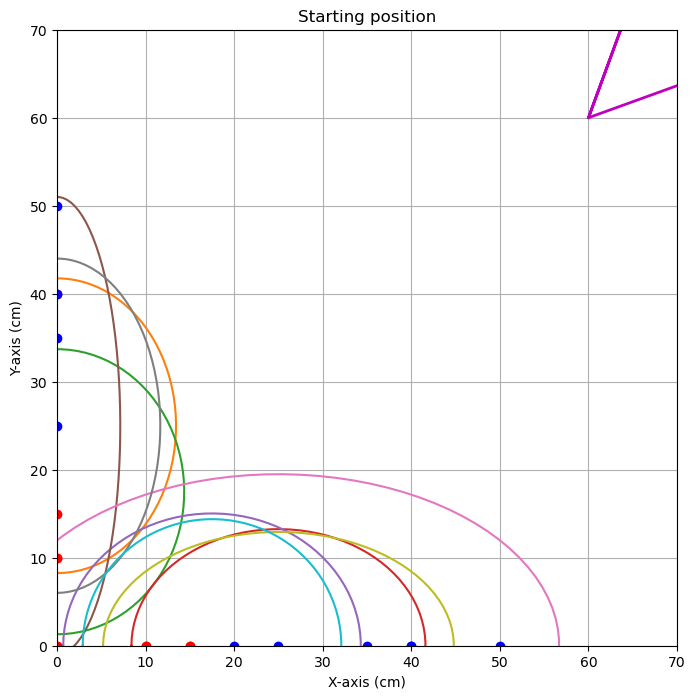


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=108.463


c:\Users\lieke\miniconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


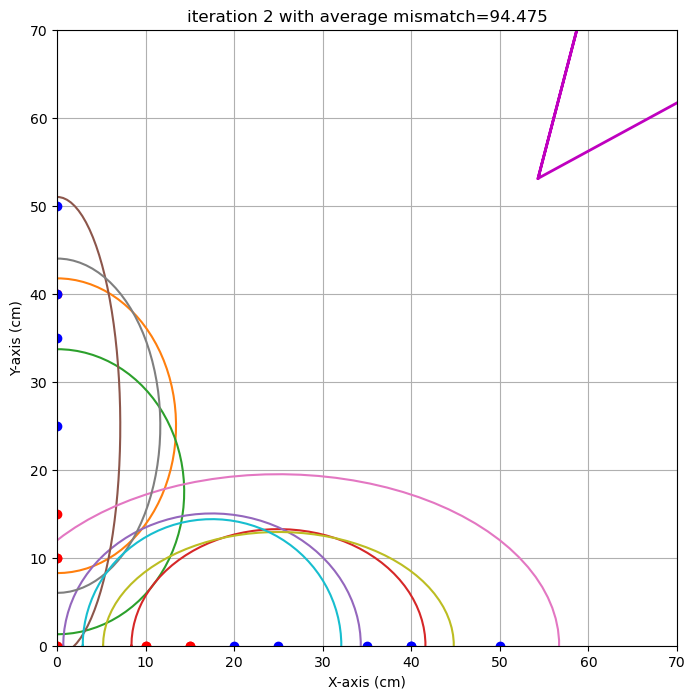

end iteration 2 with average mismatch=94.475


c:\Users\lieke\miniconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


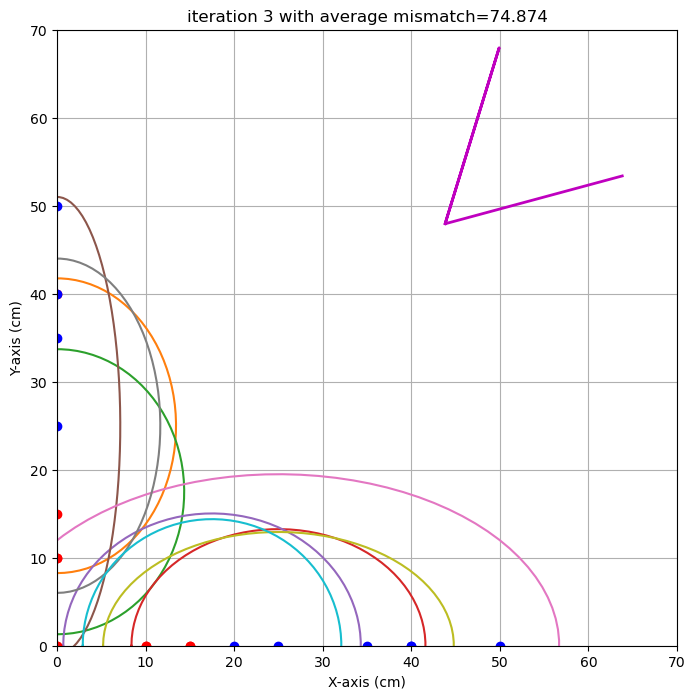

end iteration 3 with average mismatch=74.874


c:\Users\lieke\miniconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


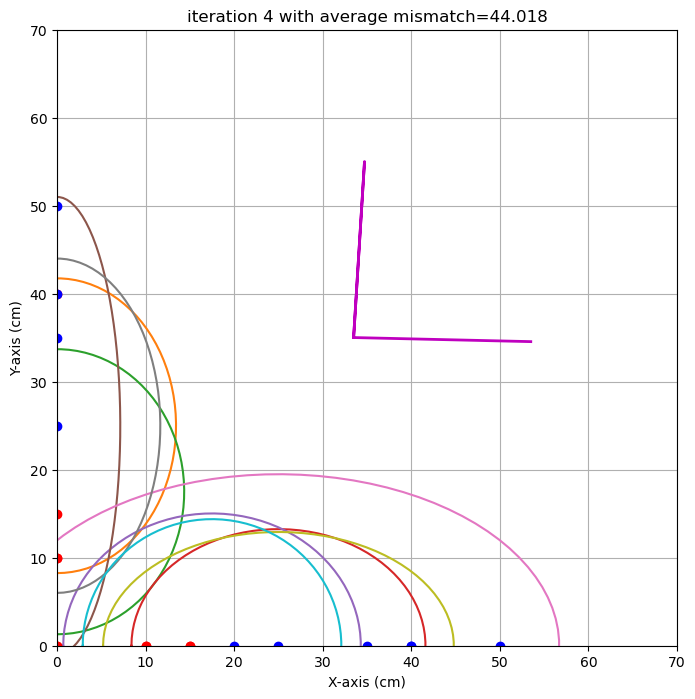

end iteration 4 with average mismatch=44.018


c:\Users\lieke\miniconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


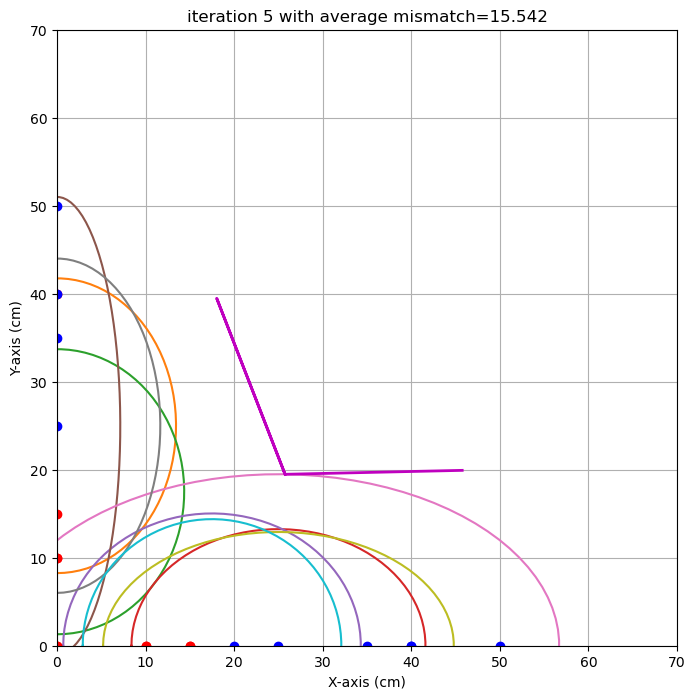

end iteration 5 with average mismatch=15.542


c:\Users\lieke\miniconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


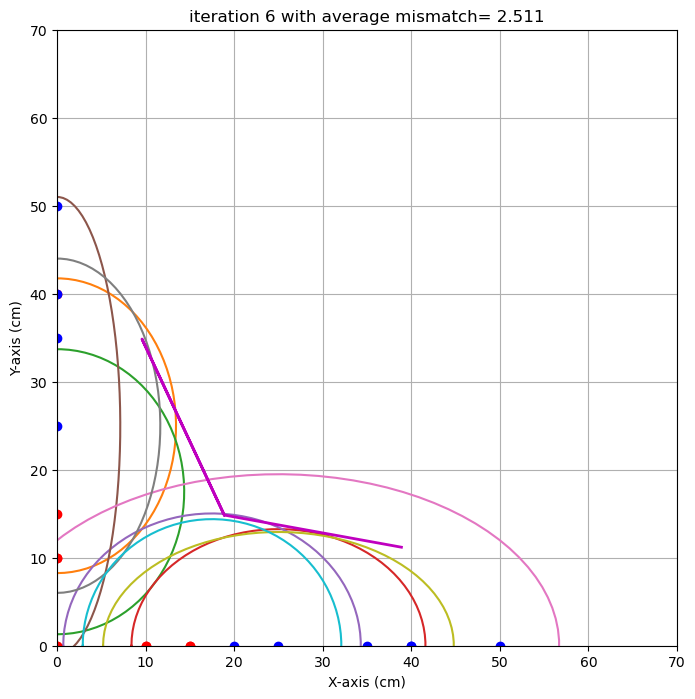

end iteration 6 with average mismatch= 2.511


c:\Users\lieke\miniconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


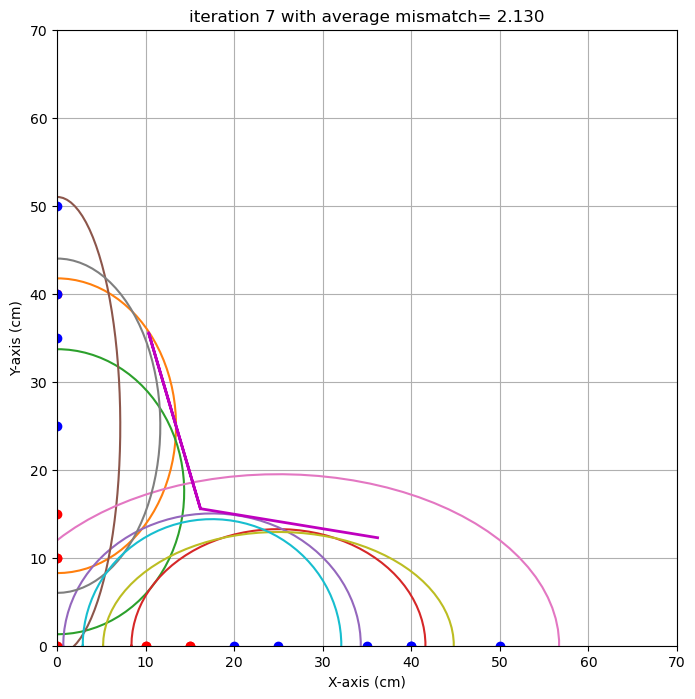

end iteration 7 with average mismatch= 2.130
end iteration 8 with average mismatch= 2.053
end iteration 9 with average mismatch= 2.036
end iteration 10 with average mismatch= 1.975
end iteration 11 with average mismatch= 1.903
end iteration 12 with average mismatch= 1.894
end iteration 13 with average mismatch= 1.866
end iteration 14 with average mismatch= 1.855
end iteration 15 with average mismatch= 1.855
end iteration 16 with average mismatch= 1.855
end iteration 17 with average mismatch= 1.832
end iteration 18 with average mismatch= 1.823
end iteration 19 with average mismatch= 1.822
end iteration 20 with average mismatch= 1.822
end iteration 21 with average mismatch= 1.822
end iteration 22 with average mismatch= 1.822
end iteration 23 with average mismatch= 1.788
end iteration 24 with average mismatch= 1.775
end iteration 25 with average mismatch= 1.771
end iteration 26 with average mismatch= 1.771
end iteration 27 with average mismatch= 1.771
end iteration 28 with average mismatc

c:\Users\lieke\miniconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


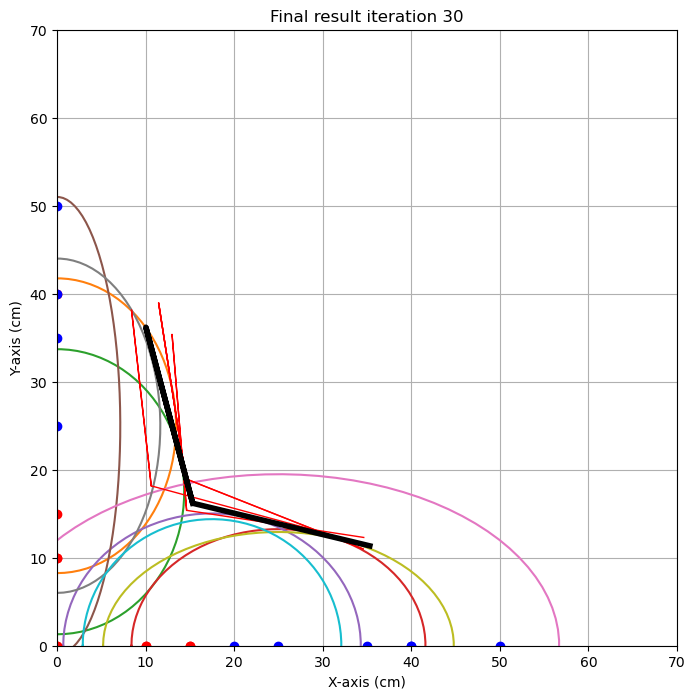

{'alpha': np.float64(-13.611562850053534), 'alpha_eps': np.float64(8.101507818513152), 'beta': np.float64(-14.802815776852768), 'beta_eps': np.float64(10.098517999301896), 'x0': np.float64(15.316393039414736), 'x0_eps': np.float64(4.678967049007191), 'y0': np.float64(16.190486474449806), 'y0_eps': np.float64(2.7720905384755987)}
locatie 1 
x0 target is : 16.0. Gevonden waarde: 11.8 cm met een standaardafwijking van 4.4 cm 
y0 target is : 19.0. Gevonden waarde: 20.0 cm met een standaardafwijking van 4.5 cm 
alpha target is : -5.0. Gevonden waarde: -18.2 graden met een standaardafwijking van 12.8 graad 
beta target is : -10.0. Gevonden waarde: -4.3 graden met een standaardafwijking van 12.2 graad 

locatie 2 
x0 target is : 17.0. Gevonden waarde: 15.3 cm met een standaardafwijking van 4.7 cm 
y0 target is : 15.0. Gevonden waarde: 16.2 cm met een standaardafwijking van 2.8 cm 
alpha target is : 10.0. Gevonden waarde: -13.6 graden met een standaardafwijking van 8.1 graad 
beta target is : 

In [62]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0': 16,
                    'y0': 19,
                    'alpha' : -5,
                    'beta' : -10,
                    },
           'locatie 2':{'x0': 17,
                    'y0': 15,
                    'alpha' : 10,
                    'beta' : -8,
                    }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0, 40, 40, 0, 55.2],
    [0,40,0,60,33.7],
    [0,30,0,60,37.1],
    [0,35,0,50,26.3],
    [0,50,0,60,125.7],
    [10,0,25,0, 36.2],
    [15,0,35,0, 37.3],
    [15,0,20,0,34.2],
    [10,0,40,0, 41.5],
    [50,0,20,0, 40.6],
    [0,25,0,50,33.7],
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,40,0,56.3],
    [0,15,0,35, 33.5],
    [0,10,0,25,32.4],
    [15,0,35,0,33.2],
    [10,0,25,0,33.6],
    [0,0,0,50,52.0],
    [0,0,50,0,63.4],
    [0,10,0,40, 38.0],
    [10,0,40,0,39.6],
    [15,0,20,0, 29.2],

    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))
    

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  30   0  60  49.8
1   0  35   0  50  44.3
2  10   0  25   0  54.8
3  15   0  35   0  54.2
4  15   0  20   0  54.7
5  10   0  40   0  57.7
6   0  10   0  60  58.6


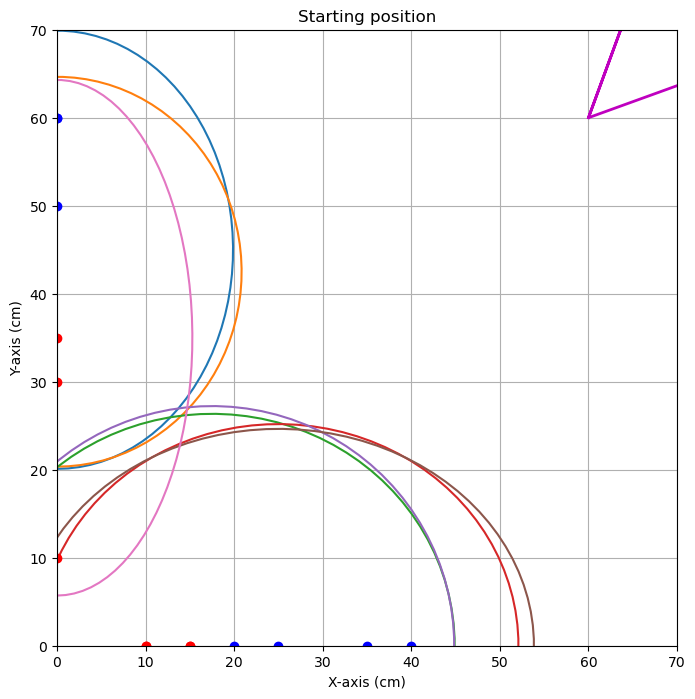


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=91.295


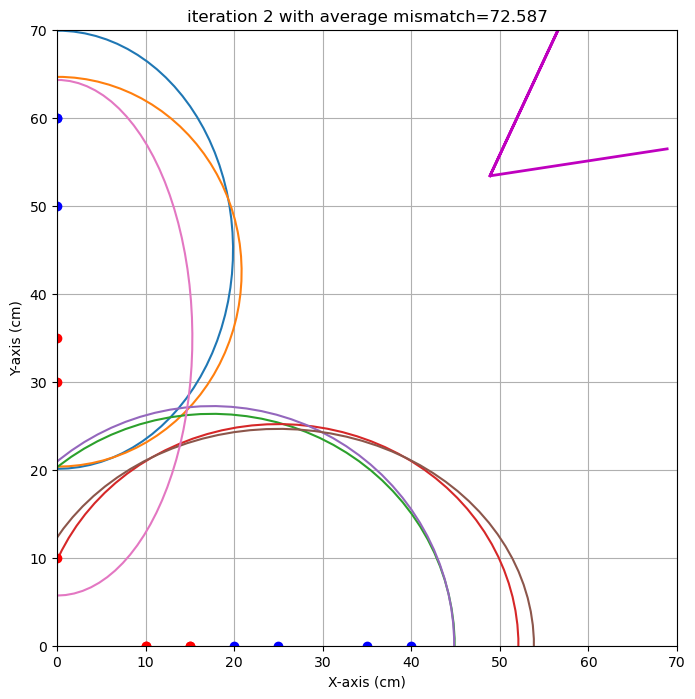

end iteration 2 with average mismatch=72.587


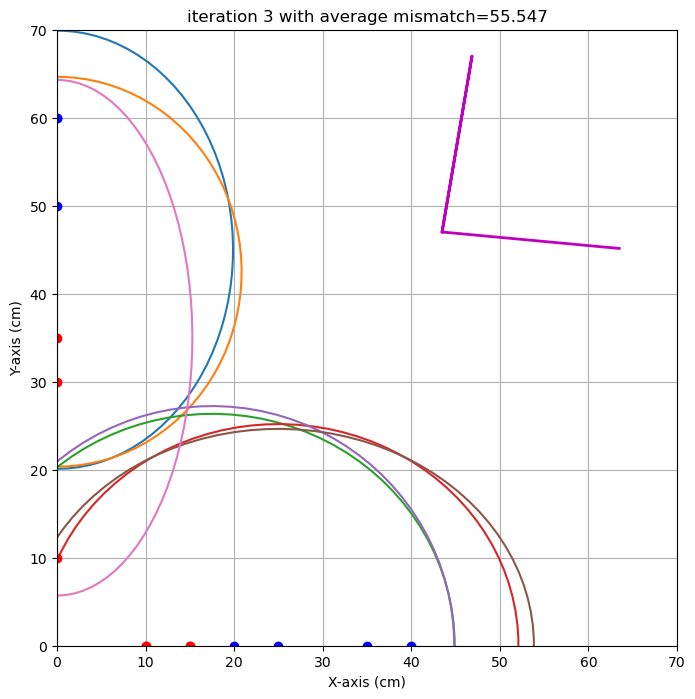

end iteration 3 with average mismatch=55.547


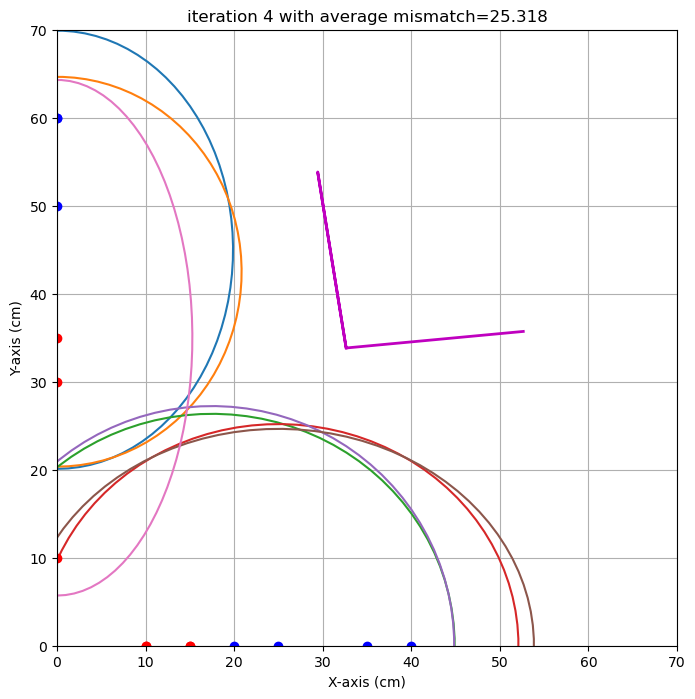

end iteration 4 with average mismatch=25.318


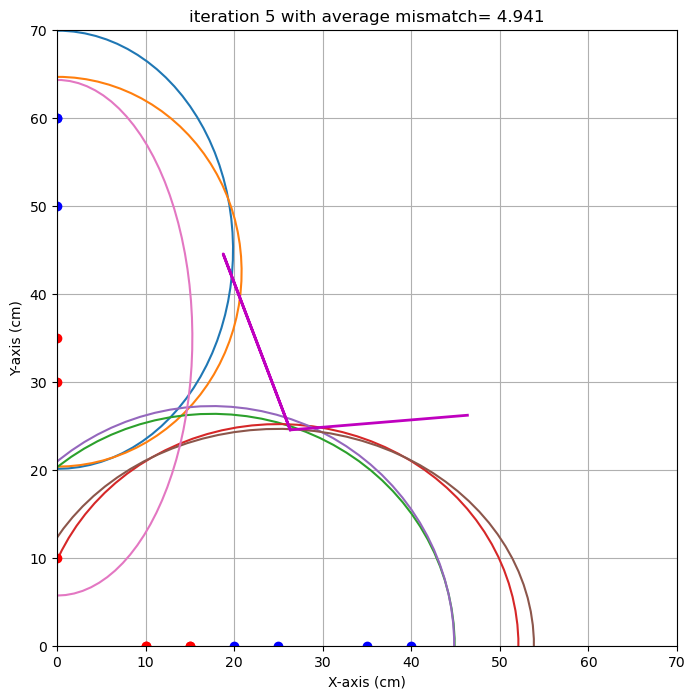

end iteration 5 with average mismatch= 4.941
end iteration 6 with average mismatch= 4.632
end iteration 7 with average mismatch= 4.467
end iteration 8 with average mismatch= 4.291


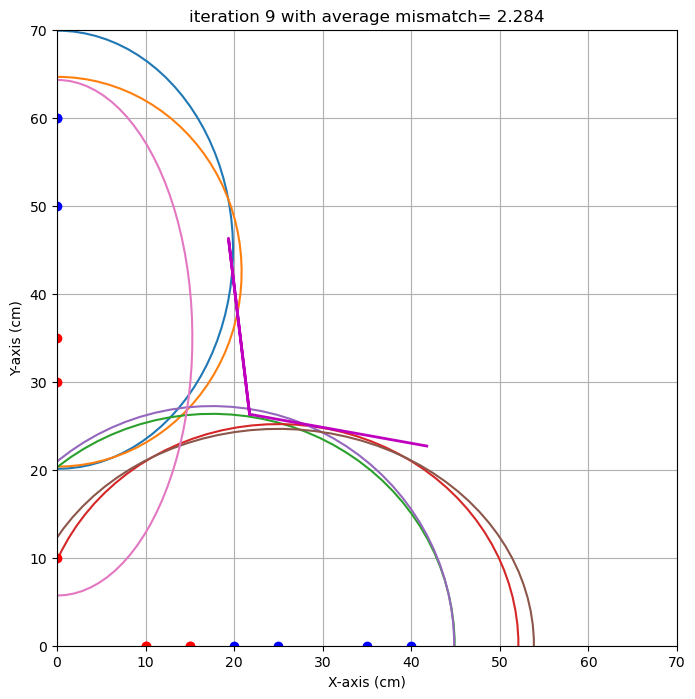

end iteration 9 with average mismatch= 2.284


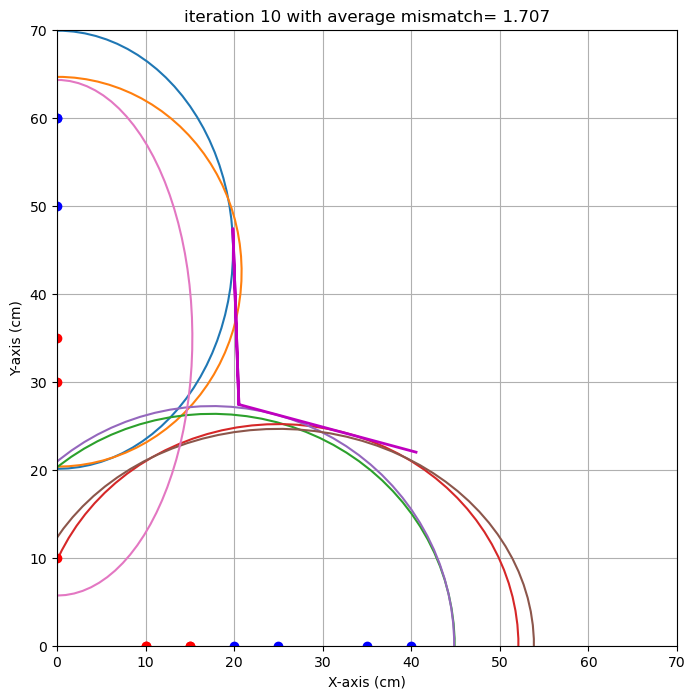

end iteration 10 with average mismatch= 1.707
end iteration 11 with average mismatch= 1.663
end iteration 12 with average mismatch= 1.657
end iteration 13 with average mismatch= 1.656
end iteration 14 with average mismatch= 1.656
end iteration 15 with average mismatch= 1.656
end iteration 16 with average mismatch= 1.656
end iteration 17 with average mismatch= 1.656
end iteration 18 with average mismatch= 1.625


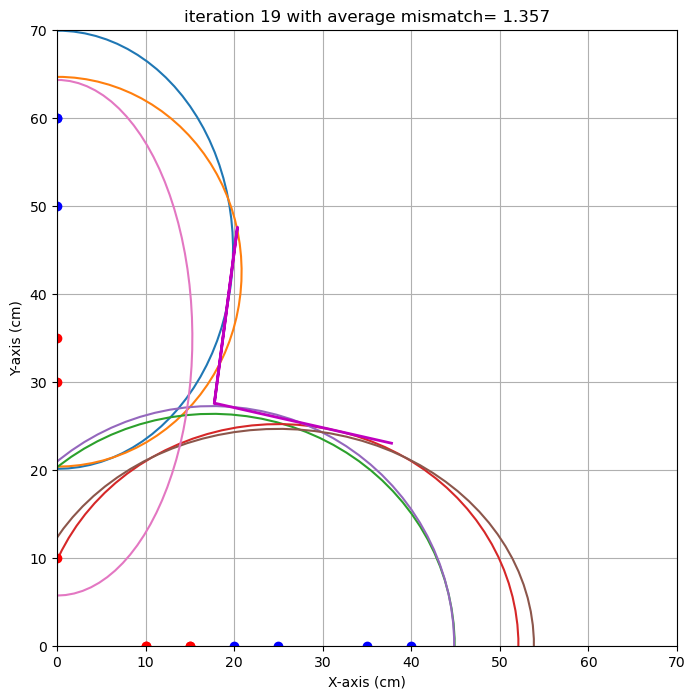

end iteration 19 with average mismatch= 1.357
end iteration 20 with average mismatch= 1.265
end iteration 21 with average mismatch= 1.265
end iteration 22 with average mismatch= 1.265
end iteration 23 with average mismatch= 1.265
end iteration 24 with average mismatch= 1.265
end iteration 25 with average mismatch= 1.265
end iteration 26 with average mismatch= 1.265
end iteration 27 with average mismatch= 1.265
end iteration 28 with average mismatch= 1.265
end iteration 29 with average mismatch= 1.265
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....


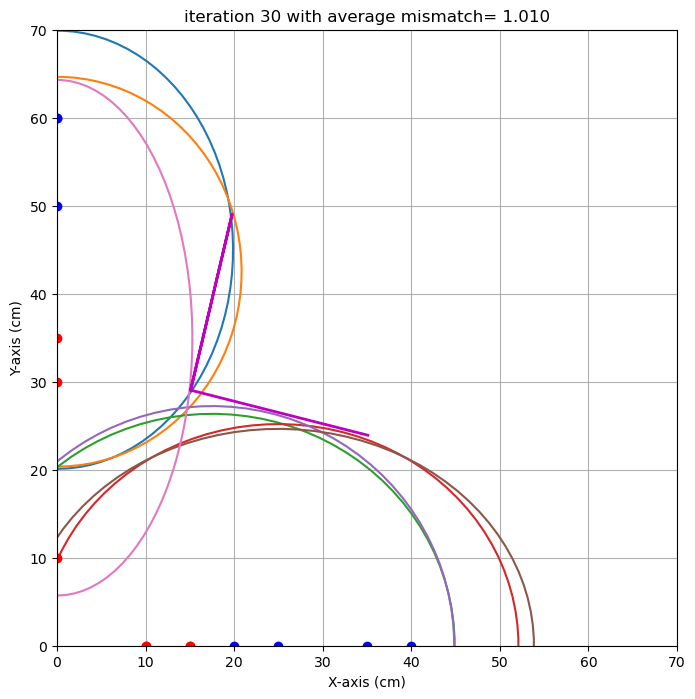

end iteration 30 with average mismatch= 1.010
###############################################################################
end of iteration  30
Best alpha= -14.36 with uncertainty=   3.64
Best beta =  13.18 with uncertainty=   1.98
Best x0   =  15.08 with uncertainty=   0.87
Best y0   =  29.04 with uncertainty=   0.81
###############################################################################


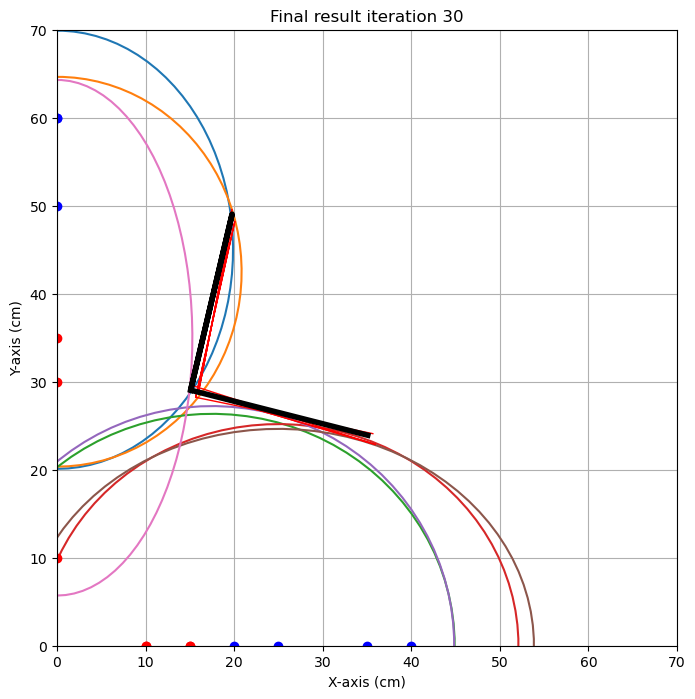

{'alpha': np.float64(-14.363283887556046), 'alpha_eps': np.float64(3.6402681973035076), 'beta': np.float64(13.181674401633312), 'beta_eps': np.float64(1.9810527169563414), 'x0': np.float64(15.082548191137857), 'x0_eps': np.float64(0.8666290464000461), 'y0': np.float64(29.04188804490848), 'y0_eps': np.float64(0.8131046435366329)}
test locatie 
x0 target is : 22.0. Gevonden waarde: 15.1 cm met een standaardafwijking van 0.9 cm 
y0 target is : 30.0. Gevonden waarde: 29.0 cm met een standaardafwijking van 0.8 cm 
alpha target is : -10.0. Gevonden waarde: -14.4 graden met een standaardafwijking van 3.6 graad 
beta target is : 10.0. Gevonden waarde: 13.2 graden met een standaardafwijking van 2.0 graad 



In [74]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':  22,
                    'y0':  30,
                    'alpha' : -10,
                    'beta' :  10,
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[0, 40, 40, 0, 51.6],
    #[0,40,0,60,50.8],
    [0,30,0,60, 49.8],
    [0,35,0,50,44.3],
    #[0,50,0,60,47.0],
    [10,0,25,0, 54.8],
    [15,0,35,0, 54.2],
    [15,0,20,0,54.7],
    [10,0,40,0, 57.7],
    #
    # [50,0,20,0, 55.6],
    #[0,25,0,50,45.4],
    [0,10,0,60,58.6],
    #[30,0,45,0, 50.1]

                    ])
                }
 
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.
Figuur: ![Alt](tudelftLogo.png "Title")

Figuur: ![Alt](tudelftLogo.png "Title")

Figuur: ![Alt](tudelftLogo.png "Title")